# Evaluación del fine-tuning YOLO26 con fotos propias

Este notebook analiza la corrida `yolo26n-peanut-own-finetune-v1` sin
volver a entrenar. Lee los artefactos persistidos, compara el checkpoint
anterior con el ajustado, grafica la evolución del entrenamiento y ejecuta
inferencia sobre **todas las imágenes del conjunto de test**.

Para cada imagen se muestran las anotaciones reales y todas las detecciones
de `best.pt` con confianza ≥ `CONFIDENCE` después de NMS. También se imprime
una tabla completa con confianza, coordenadas, IoU y estado TP/FP.

Kernel recomendado:
`/home/enzo/Desktop/CbaHack/cv/.notebook-venv/bin/python`
(`CbaHack YOLO Notebook`). Las salidas de la ejecución quedan guardadas
dentro de este archivo `.ipynb`.


In [1]:
import os
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/tmp/cbahack-matplotlib")
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

import csv
import json

import matplotlib.pyplot as plt
import numpy as np
import torch
import yaml
from IPython.display import Markdown, display
from PIL import Image, ImageDraw, ImageFont
from ultralytics import YOLO

RUN_NAME = "yolo26n-peanut-own-finetune-v1"
CONFIDENCE = 0.25
PREDICTION_IOU = 0.70
MATCH_IOU = 0.50
IMAGES_PER_PAGE = 4


def locate_repo_root(start: Path) -> Path:
    for candidate in [start.resolve(), *start.resolve().parents]:
        if (candidate / "cv" / "scripts" / "fine_tune_own_yolo26.py").is_file():
            return candidate
    raise FileNotFoundError(
        "No se encontró la raíz de CbaHack. Abra el notebook desde el "
        "repositorio o ajuste REPO_ROOT manualmente."
    )


REPO_ROOT = locate_repo_root(Path.cwd())
CV_ROOT = REPO_ROOT / "cv"
RUN_DIR = CV_ROOT / "Models-Roboflow" / RUN_NAME
SUMMARY_PATH = RUN_DIR / "run_summary.json"
RESULTS_CSV = RUN_DIR / "results.csv"

if not SUMMARY_PATH.is_file():
    raise FileNotFoundError(f"No existe el resumen de la corrida: {SUMMARY_PATH}")
summary = json.loads(SUMMARY_PATH.read_text(encoding="utf-8"))
if summary.get("status") != "completed":
    raise RuntimeError(
        f"La corrida no está completa. Estado: {summary.get('status')!r}"
    )

SOURCE_PT = Path(summary["checkpoints"]["source"])
BEST_PT = Path(summary["checkpoints"]["best"])
LAST_PT = Path(summary["checkpoints"]["last"])
for checkpoint in (SOURCE_PT, BEST_PT, LAST_PT):
    if not checkpoint.is_file():
        raise FileNotFoundError(f"No se encontró el checkpoint: {checkpoint}")

DEVICE = 0 if torch.cuda.is_available() else "cpu"
print(f"Repositorio:       {REPO_ROOT}")
print(f"Corrida:           {RUN_DIR}")
print(f"Checkpoint fuente: {SOURCE_PT}")
print(f"Checkpoint final:  {BEST_PT}")
print(f"Dispositivo:       {DEVICE}")
print(f"PyTorch:           {torch.__version__}")


Repositorio:       /home/enzo/Desktop/CbaHack
Corrida:           /home/enzo/Desktop/CbaHack/cv/Models-Roboflow/yolo26n-peanut-own-finetune-v1
Checkpoint fuente: /home/enzo/Desktop/CbaHack/cv/Models-Roboflow/yolo26n-peanut-50pct-50e-v1/weights/best.pt
Checkpoint final:  /home/enzo/Desktop/CbaHack/cv/Models-Roboflow/yolo26n-peanut-own-finetune-v1/weights/best.pt
Dispositivo:       0
PyTorch:           2.7.0+cu128


## 1. Configuración y dataset utilizados

La información proviene de `run_summary.json`; no se infieren parámetros
a partir del nombre de la corrida.


In [2]:
config = summary.get("effective_config", {})
dataset_summary = summary.get("dataset", {})
duration_minutes = float(summary.get("duration_seconds", 0)) / 60

rows = [
    ("Estado", summary.get("status")),
    ("Duración total", f"{duration_minutes:.1f} min"),
    ("Épocas ejecutadas", config.get("epochs")),
    ("Resolución", config.get("image_size")),
    ("Batch", config.get("batch")),
    ("Capas congeladas", config.get("freeze_layers")),
    ("Optimizador", config.get("optimizer")),
    ("Learning rate inicial", config.get("learning_rate")),
    ("Dispositivo", config.get("device_description")),
    ("AMP", config.get("amp")),
    ("Imágenes train/val/test", dataset_summary.get("split_counts")),
    ("Cajas train/val/test", dataset_summary.get("annotation_counts")),
    ("Checkpoint inicial", SOURCE_PT.name),
    ("Checkpoint seleccionado", BEST_PT.name),
]
table = ["| Campo | Valor |", "|---|---|"]
table.extend(f"| {field} | `{value}` |" for field, value in rows)
display(Markdown("\n".join(table)))

split_manifest_path = RUN_DIR / "split_manifest.json"
split_manifest = json.loads(split_manifest_path.read_text(encoding="utf-8"))
split_rows = [
    (
        split,
        details["images"],
        details["annotations"],
        len(details["capture_groups"]),
        details["source_counts"].get("photos_session_01", 0),
        details["source_counts"].get("video_frames_session_02", 0),
    )
    for split, details in split_manifest["splits"].items()
]
table = [
    "| Split | Imágenes | Cajas | Grupos | Fotos | Frames de video |",
    "|---|---:|---:|---:|---:|---:|",
]
table.extend(
    f"| {split} | {images} | {boxes} | {groups} | {photos} | {video} |"
    for split, images, boxes, groups, photos, video in split_rows
)
display(Markdown("\n".join(table)))


| Campo | Valor |
|---|---|
| Estado | `completed` |
| Duración total | `6.2 min` |
| Épocas ejecutadas | `45` |
| Resolución | `768` |
| Batch | `-1` |
| Capas congeladas | `10` |
| Optimizador | `AdamW` |
| Learning rate inicial | `0.001` |
| Dispositivo | `CUDA 0` |
| AMP | `True` |
| Imágenes train/val/test | `{'train': 53, 'val': 11, 'test': 12}` |
| Cajas train/val/test | `{'train': 380, 'val': 83, 'test': 92}` |
| Checkpoint inicial | `best.pt` |
| Checkpoint seleccionado | `best.pt` |

| Split | Imágenes | Cajas | Grupos | Fotos | Frames de video |
|---|---:|---:|---:|---:|---:|
| train | 53 | 380 | 10 | 30 | 23 |
| val | 11 | 83 | 2 | 3 | 8 |
| test | 12 | 92 | 2 | 3 | 9 |

## 2. Curvas del fine-tuning

Se destaca la época con mayor `mAP50-95` en validación. La selección del
checkpoint se hace con `val`, nunca con `test`.


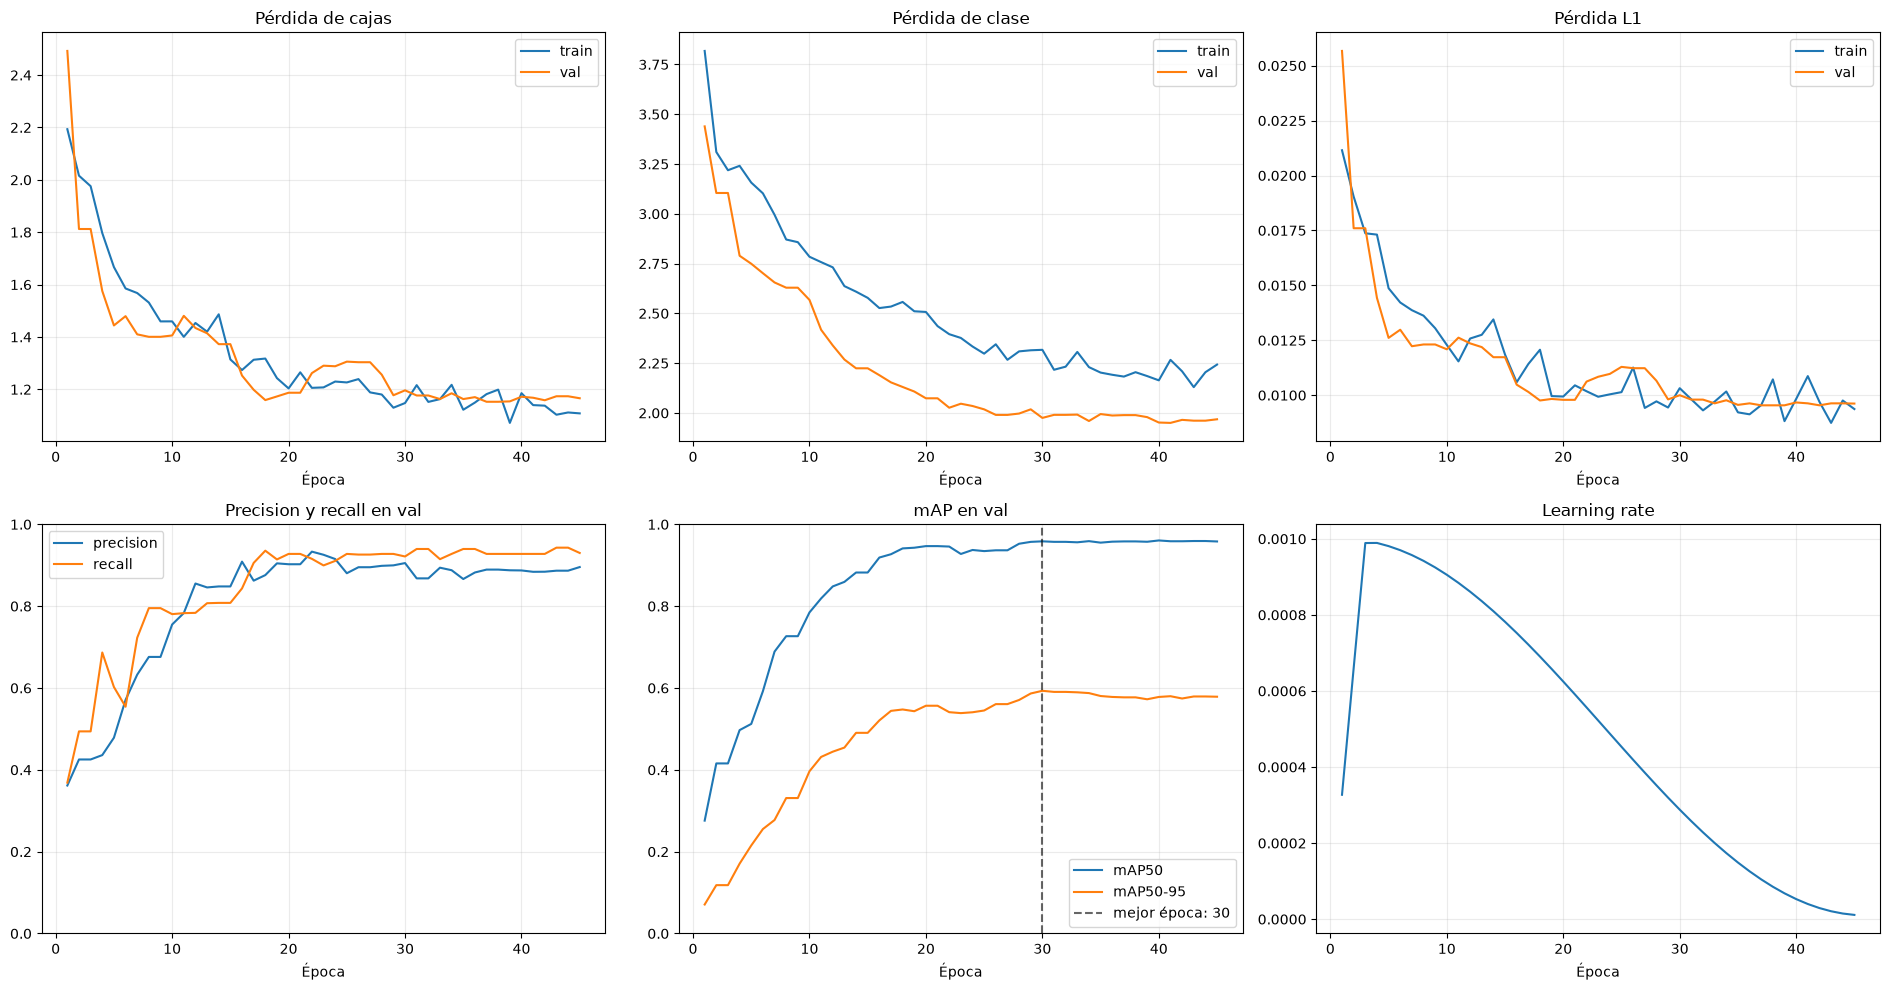

**Mejor época según val:** 30  
**Precision:** 0.9053 · **Recall:** 0.9214 · **mAP50:** 0.9585 · **mAP50-95:** 0.5931

In [3]:
if not RESULTS_CSV.is_file():
    raise FileNotFoundError(f"No existe {RESULTS_CSV}")

with RESULTS_CSV.open(encoding="utf-8", newline="") as handle:
    raw_history = list(csv.DictReader(handle))
history = [
    {key.strip(): float(value) for key, value in row.items()}
    for row in raw_history
]
epochs = np.asarray([row["epoch"] for row in history], dtype=int)
best_index = int(np.argmax([row["metrics/mAP50-95(B)"] for row in history]))
best_epoch = int(epochs[best_index])
best_row = history[best_index]

fig, axes = plt.subplots(2, 3, figsize=(19, 10))
loss_pairs = [
    ("box_loss", "Pérdida de cajas"),
    ("cls_loss", "Pérdida de clase"),
    ("l1_loss", "Pérdida L1"),
]
for axis, (loss_name, title) in zip(axes[0], loss_pairs):
    axis.plot(epochs, [row[f"train/{loss_name}"] for row in history], label="train")
    axis.plot(epochs, [row[f"val/{loss_name}"] for row in history], label="val")
    axis.set_title(title)
    axis.legend()

axes[1, 0].plot(
    epochs,
    [row["metrics/precision(B)"] for row in history],
    label="precision",
)
axes[1, 0].plot(
    epochs,
    [row["metrics/recall(B)"] for row in history],
    label="recall",
)
axes[1, 0].set_title("Precision y recall en val")
axes[1, 0].set_ylim(0, 1)
axes[1, 0].legend()

axes[1, 1].plot(
    epochs,
    [row["metrics/mAP50(B)"] for row in history],
    label="mAP50",
)
axes[1, 1].plot(
    epochs,
    [row["metrics/mAP50-95(B)"] for row in history],
    label="mAP50-95",
)
axes[1, 1].axvline(
    best_epoch,
    color="black",
    linestyle="--",
    alpha=0.6,
    label=f"mejor época: {best_epoch}",
)
axes[1, 1].set_title("mAP en val")
axes[1, 1].set_ylim(0, 1)
axes[1, 1].legend()

axes[1, 2].plot(epochs, [row["lr/pg0"] for row in history])
axes[1, 2].set_title("Learning rate")

for axis in axes.flat:
    axis.set_xlabel("Época")
    axis.grid(alpha=0.25)
plt.tight_layout()
plt.show()

display(Markdown(
    f"**Mejor época según val:** {best_epoch}  \n"
    f"**Precision:** {best_row['metrics/precision(B)']:.4f} · "
    f"**Recall:** {best_row['metrics/recall(B)']:.4f} · "
    f"**mAP50:** {best_row['metrics/mAP50(B)']:.4f} · "
    f"**mAP50-95:** {best_row['metrics/mAP50-95(B)']:.4f}"
))


## 3. Comparación antes y después del fine-tuning

El pipeline evaluó el checkpoint original y `best.pt` sobre exactamente
los mismos splits propios. Esto mide la adaptación al dominio de las
fotografías nuevas.


| Split | Métrica | Antes | Después | Diferencia |
|---|---|---:|---:|---:|
| val | Precision | 0.0005 | 0.9053 | +0.9047 |
| val | Recall | 0.0120 | 0.9214 | +0.9094 |
| val | mAP50 | 0.0000 | 0.9587 | +0.9587 |
| val | mAP75 | 0.0000 | 0.7214 | +0.7214 |
| val | mAP50-95 | 0.0000 | 0.5933 | +0.5933 |
| test | Precision | 0.0000 | 0.8600 | +0.8600 |
| test | Recall | 0.0000 | 0.8677 | +0.8677 |
| test | mAP50 | 0.0000 | 0.9156 | +0.9156 |
| test | mAP75 | 0.0000 | 0.7262 | +0.7262 |
| test | mAP50-95 | 0.0000 | 0.5831 | +0.5831 |

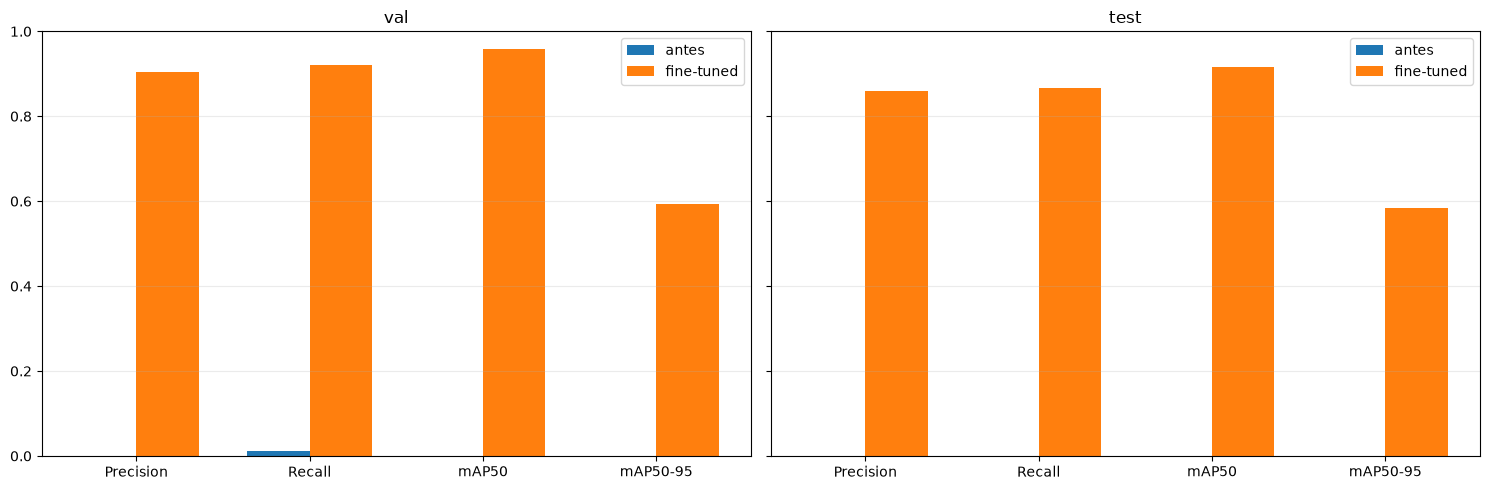

In [4]:
baseline_metrics = json.loads(
    (RUN_DIR / "baseline_metrics.json").read_text(encoding="utf-8")
)
fine_tuned_metrics = {
    split: json.loads(
        (RUN_DIR / f"{split}_metrics.json").read_text(encoding="utf-8")
    )
    for split in ("val", "test")
}
metric_labels = {
    "precision": "Precision",
    "recall": "Recall",
    "map50": "mAP50",
    "map75": "mAP75",
    "map50_95": "mAP50-95",
}
table = [
    "| Split | Métrica | Antes | Después | Diferencia |",
    "|---|---|---:|---:|---:|",
]
for split in ("val", "test"):
    for key, label in metric_labels.items():
        before = float(baseline_metrics[split][key])
        after = float(fine_tuned_metrics[split][key])
        table.append(
            f"| {split} | {label} | {before:.4f} | {after:.4f} | {after-before:+.4f} |"
        )
display(Markdown("\n".join(table)))

figure, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
keys = ["precision", "recall", "map50", "map50_95"]
positions = np.arange(len(keys))
width = 0.36
for axis, split in zip(axes, ("val", "test")):
    axis.bar(
        positions - width / 2,
        [baseline_metrics[split][key] for key in keys],
        width,
        label="antes",
    )
    axis.bar(
        positions + width / 2,
        [fine_tuned_metrics[split][key] for key in keys],
        width,
        label="fine-tuned",
    )
    axis.set_xticks(positions, [metric_labels[key] for key in keys])
    axis.set_ylim(0, 1)
    axis.set_title(split)
    axis.grid(axis="y", alpha=0.25)
    axis.legend()
plt.tight_layout()
plt.show()


## 4. Curvas y matriz de confusión sobre test

Estos gráficos fueron producidos por la evaluación explícita del mejor
checkpoint al finalizar la corrida.


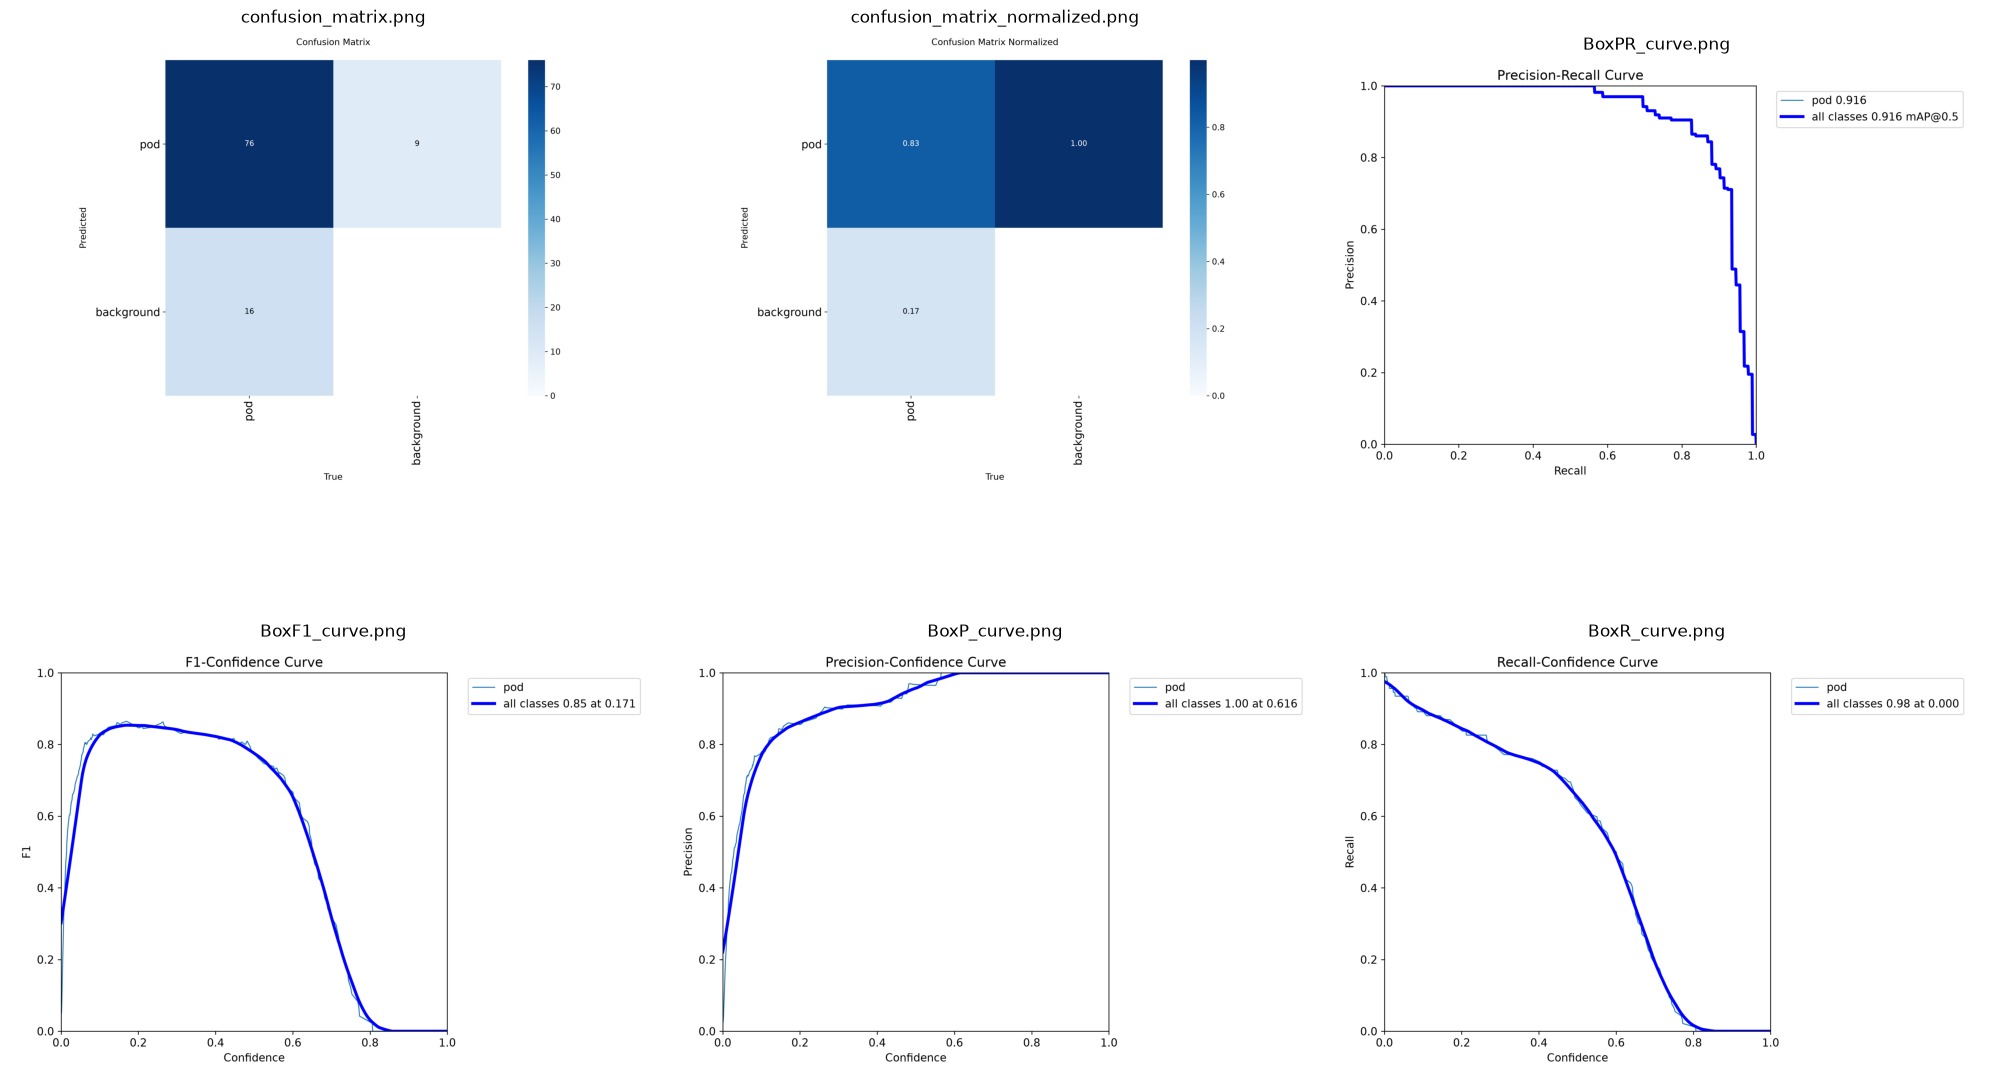

In [5]:
artifact_root = RUN_DIR / "evaluation_finetuned" / "test"
artifact_names = [
    "confusion_matrix.png",
    "confusion_matrix_normalized.png",
    "BoxPR_curve.png",
    "BoxF1_curve.png",
    "BoxP_curve.png",
    "BoxR_curve.png",
]
artifacts = [artifact_root / name for name in artifact_names]
missing_artifacts = [path for path in artifacts if not path.is_file()]
if missing_artifacts:
    raise FileNotFoundError(f"Faltan artefactos: {missing_artifacts}")

fig, axes = plt.subplots(2, 3, figsize=(20, 13))
for axis, path in zip(axes.flat, artifacts):
    axis.imshow(plt.imread(path))
    axis.set_title(path.name)
    axis.axis("off")
plt.tight_layout()
plt.show()


## 5. Carga del test y ejecución de todas las detecciones

Se usa el split registrado por la corrida. La inferencia se realiza una
sola vez para las 12 imágenes y luego se reutilizan esos resultados en
las visualizaciones y tablas siguientes.


In [6]:
DATASET_DIR = Path(dataset_summary["directory"])
DATA_YAML = Path(dataset_summary["data_yaml"])
data_config = yaml.safe_load(DATA_YAML.read_text(encoding="utf-8"))
TEST_IMAGES_DIR = DATASET_DIR / "images" / "test"
TEST_LABELS_DIR = DATASET_DIR / "labels" / "test"
test_images = sorted(
    path
    for path in TEST_IMAGES_DIR.iterdir()
    if path.suffix.lower() in {".jpg", ".jpeg", ".png"}
)
expected_test_images = int(dataset_summary["split_counts"]["test"])
if len(test_images) != expected_test_images:
    raise RuntimeError(
        f"Se esperaban {expected_test_images} imágenes de test y se encontraron "
        f"{len(test_images)}."
    )

normalized_manifest_path = DATASET_DIR.parent.parent / "all" / "manifest.json"
normalized_manifest = json.loads(
    normalized_manifest_path.read_text(encoding="utf-8")
)
metadata_by_name = {
    item["prepared_name"]: item for item in normalized_manifest["images"]
}

model = YOLO(str(BEST_PT))
IMAGE_SIZE = int(config["image_size"])
prediction_results = model.predict(
    source=[str(path) for path in test_images],
    imgsz=IMAGE_SIZE,
    conf=CONFIDENCE,
    iou=PREDICTION_IOU,
    max_det=1000,
    device=DEVICE,
    verbose=False,
)
if len(prediction_results) != len(test_images):
    raise RuntimeError("Ultralytics no devolvió un resultado por imagen.")

print(f"Clase:                  {data_config['names']}")
print(f"Imágenes procesadas:    {len(test_images)} / {expected_test_images}")
print(f"Resolución de entrada:  {IMAGE_SIZE}")
print(f"Umbral de confianza:    {CONFIDENCE}")
print(f"IoU de NMS:             {PREDICTION_IOU}")
print(f"IoU para TP/FP:         {MATCH_IOU}")


Clase:                  {0: 'pod'}
Imágenes procesadas:    12 / 12
Resolución de entrada:  768
Umbral de confianza:    0.25
IoU de NMS:             0.7
IoU para TP/FP:         0.5


In [7]:
def read_ground_truth(image_path: Path) -> np.ndarray:
    label_path = TEST_LABELS_DIR / f"{image_path.stem}.txt"
    if not label_path.is_file():
        raise FileNotFoundError(f"Falta la etiqueta: {label_path}")
    with Image.open(image_path) as image:
        image_width, image_height = image.size
    boxes = []
    for line in label_path.read_text(encoding="utf-8").splitlines():
        if not line.strip():
            continue
        class_id, x_center, y_center, width, height = map(float, line.split())
        if int(class_id) != 0:
            raise ValueError(f"Clase inesperada en {label_path}: {class_id}")
        boxes.append(
            (
                (x_center - width / 2) * image_width,
                (y_center - height / 2) * image_height,
                (x_center + width / 2) * image_width,
                (y_center + height / 2) * image_height,
            )
        )
    return np.asarray(boxes, dtype=float).reshape(-1, 4)


def iou_matrix(predicted: np.ndarray, ground_truth: np.ndarray) -> np.ndarray:
    if len(predicted) == 0 or len(ground_truth) == 0:
        return np.zeros((len(predicted), len(ground_truth)), dtype=float)
    top_left = np.maximum(predicted[:, None, :2], ground_truth[None, :, :2])
    bottom_right = np.minimum(predicted[:, None, 2:], ground_truth[None, :, 2:])
    intersection_size = np.clip(bottom_right - top_left, 0, None)
    intersection = intersection_size[..., 0] * intersection_size[..., 1]
    predicted_area = np.prod(
        np.clip(predicted[:, 2:] - predicted[:, :2], 0, None), axis=1
    )
    ground_truth_area = np.prod(
        np.clip(ground_truth[:, 2:] - ground_truth[:, :2], 0, None), axis=1
    )
    union = predicted_area[:, None] + ground_truth_area[None, :] - intersection
    return np.divide(
        intersection,
        union,
        out=np.zeros_like(intersection),
        where=union > 0,
    )


def match_predictions(
    predicted: np.ndarray,
    confidences: np.ndarray,
    ground_truth: np.ndarray,
    threshold: float,
) -> tuple[list[str], list[int | None], list[float]]:
    statuses = ["FP"] * len(predicted)
    matched_gt: list[int | None] = [None] * len(predicted)
    matched_ious = [0.0] * len(predicted)
    if len(predicted) == 0 or len(ground_truth) == 0:
        return statuses, matched_gt, matched_ious
    overlaps = iou_matrix(predicted, ground_truth)
    unmatched_ground_truth = set(range(len(ground_truth)))
    for prediction_index in np.argsort(-confidences):
        candidates = sorted(unmatched_ground_truth)
        if not candidates:
            break
        candidate_ious = overlaps[prediction_index, candidates]
        best_local_index = int(np.argmax(candidate_ious))
        best_gt = candidates[best_local_index]
        best_iou = float(candidate_ious[best_local_index])
        if best_iou >= threshold:
            statuses[prediction_index] = "TP"
            matched_gt[prediction_index] = best_gt
            matched_ious[prediction_index] = best_iou
            unmatched_ground_truth.remove(best_gt)
    return statuses, matched_gt, matched_ious


analyses = []
for image_path, result in zip(test_images, prediction_results):
    gt_boxes = read_ground_truth(image_path)
    if result.boxes is None or len(result.boxes) == 0:
        pred_boxes = np.empty((0, 4), dtype=float)
        confidences = np.empty((0,), dtype=float)
    else:
        pred_boxes = result.boxes.xyxy.detach().cpu().numpy()
        confidences = result.boxes.conf.detach().cpu().numpy()
    statuses, matched_gt, matched_ious = match_predictions(
        pred_boxes,
        confidences,
        gt_boxes,
        MATCH_IOU,
    )
    analyses.append(
        {
            "image_path": image_path,
            "ground_truth": gt_boxes,
            "predicted": pred_boxes,
            "confidences": confidences,
            "statuses": statuses,
            "matched_gt": matched_gt,
            "matched_ious": matched_ious,
            "capture_group": metadata_by_name[image_path.name]["capture_group"],
            "original_file_name": metadata_by_name[image_path.name]["original_file_name"],
        }
    )

total_detections = sum(len(item["predicted"]) for item in analyses)
total_ground_truth = sum(len(item["ground_truth"]) for item in analyses)
print(f"Anotaciones reales cargadas: {total_ground_truth}")
print(f"Detecciones encontradas:     {total_detections}")


Anotaciones reales cargadas: 92
Detecciones encontradas:     84


## 6. Todas las imágenes de test con todas sus detecciones

- Izquierda: anotaciones reales en verde.
- Derecha: detecciones verdaderas positivas en azul y falsos positivos
  en rojo, usando IoU ≥ 0.50 para el emparejamiento.
- `Pxx` identifica cada predicción y coincide con la tabla de la sección 7.


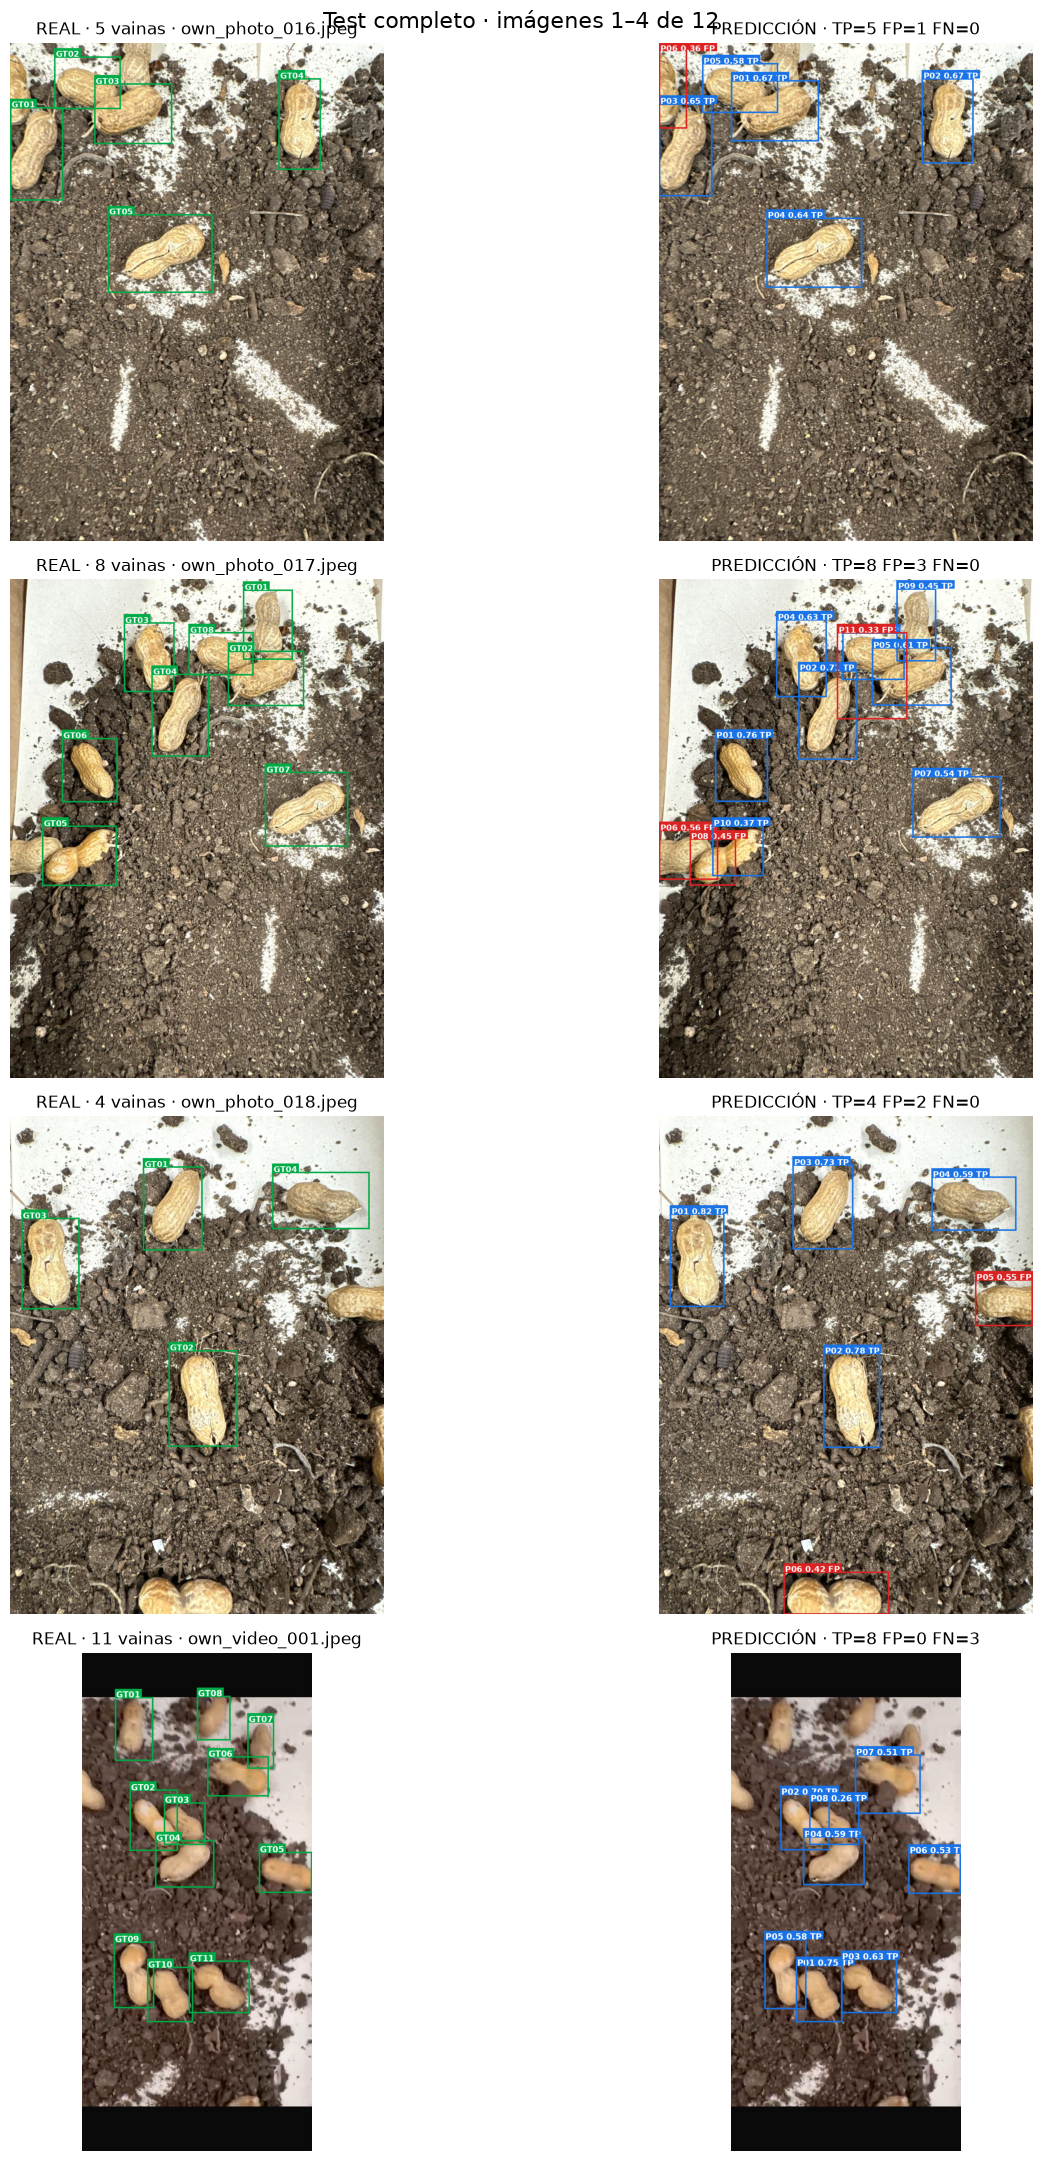

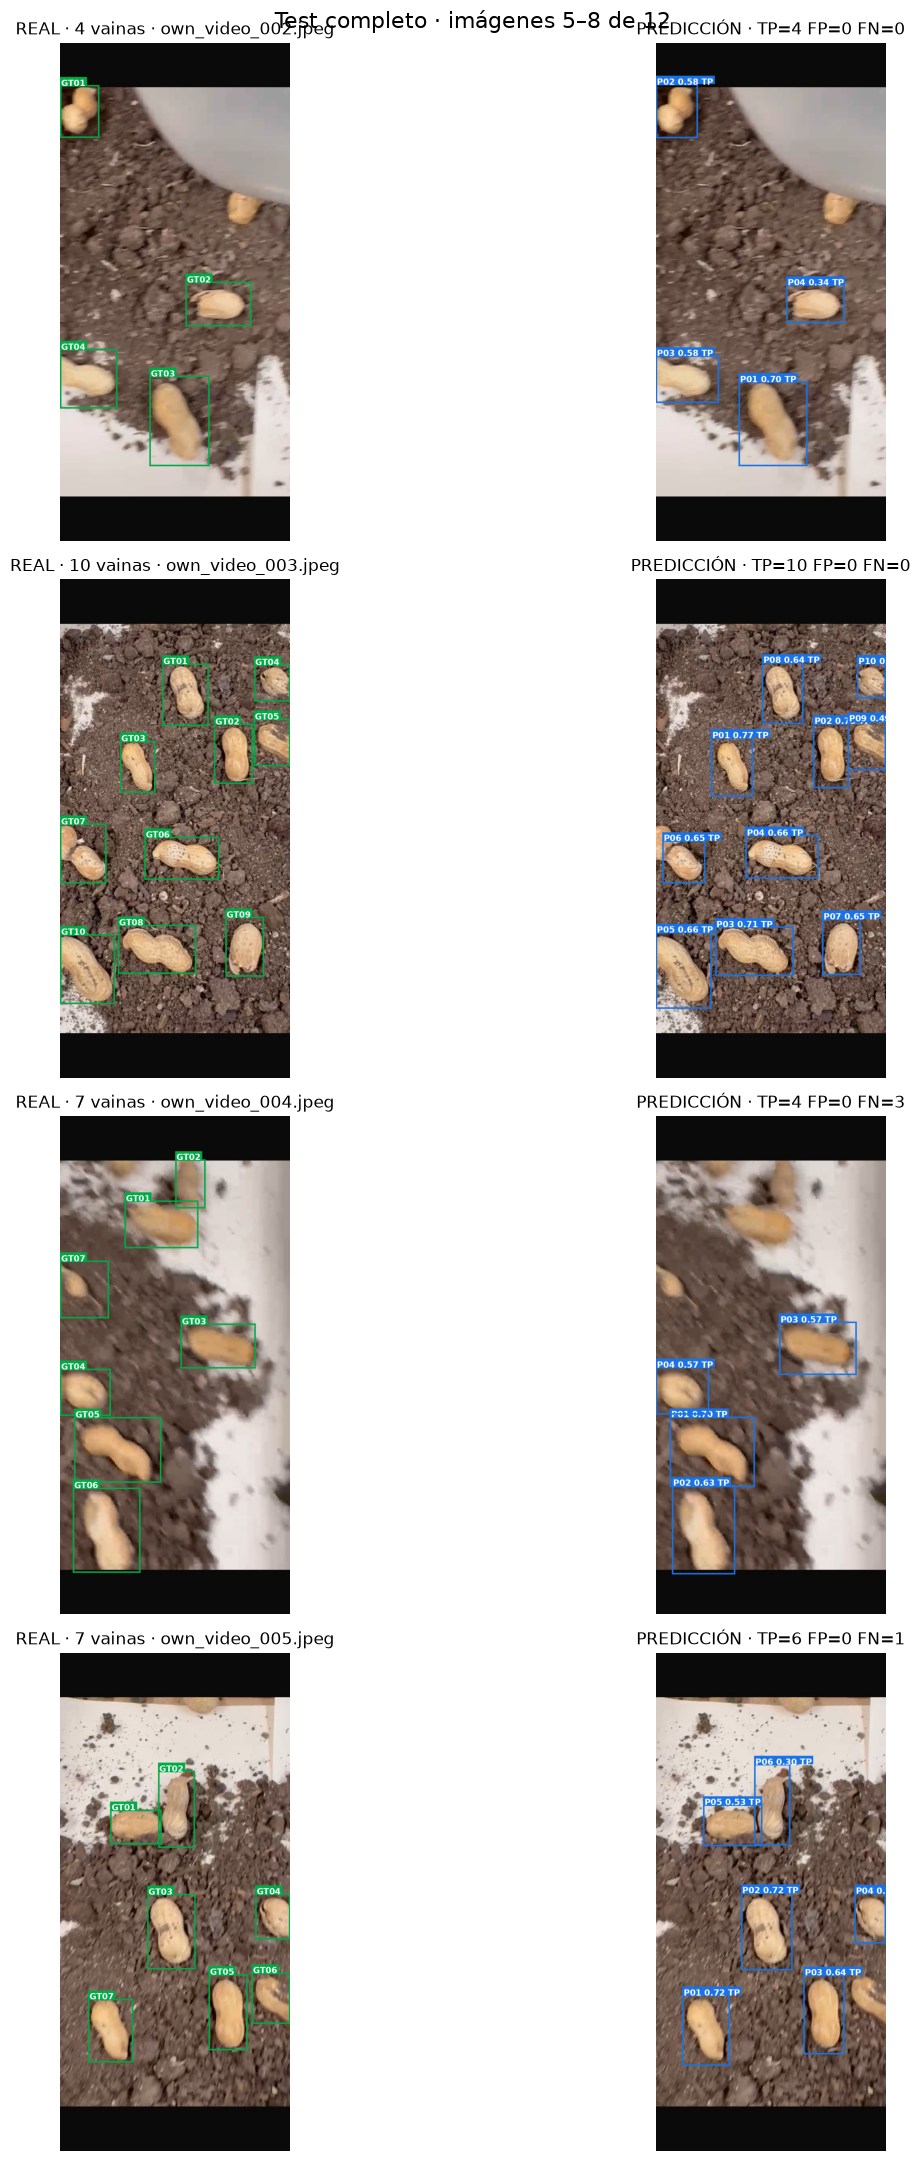

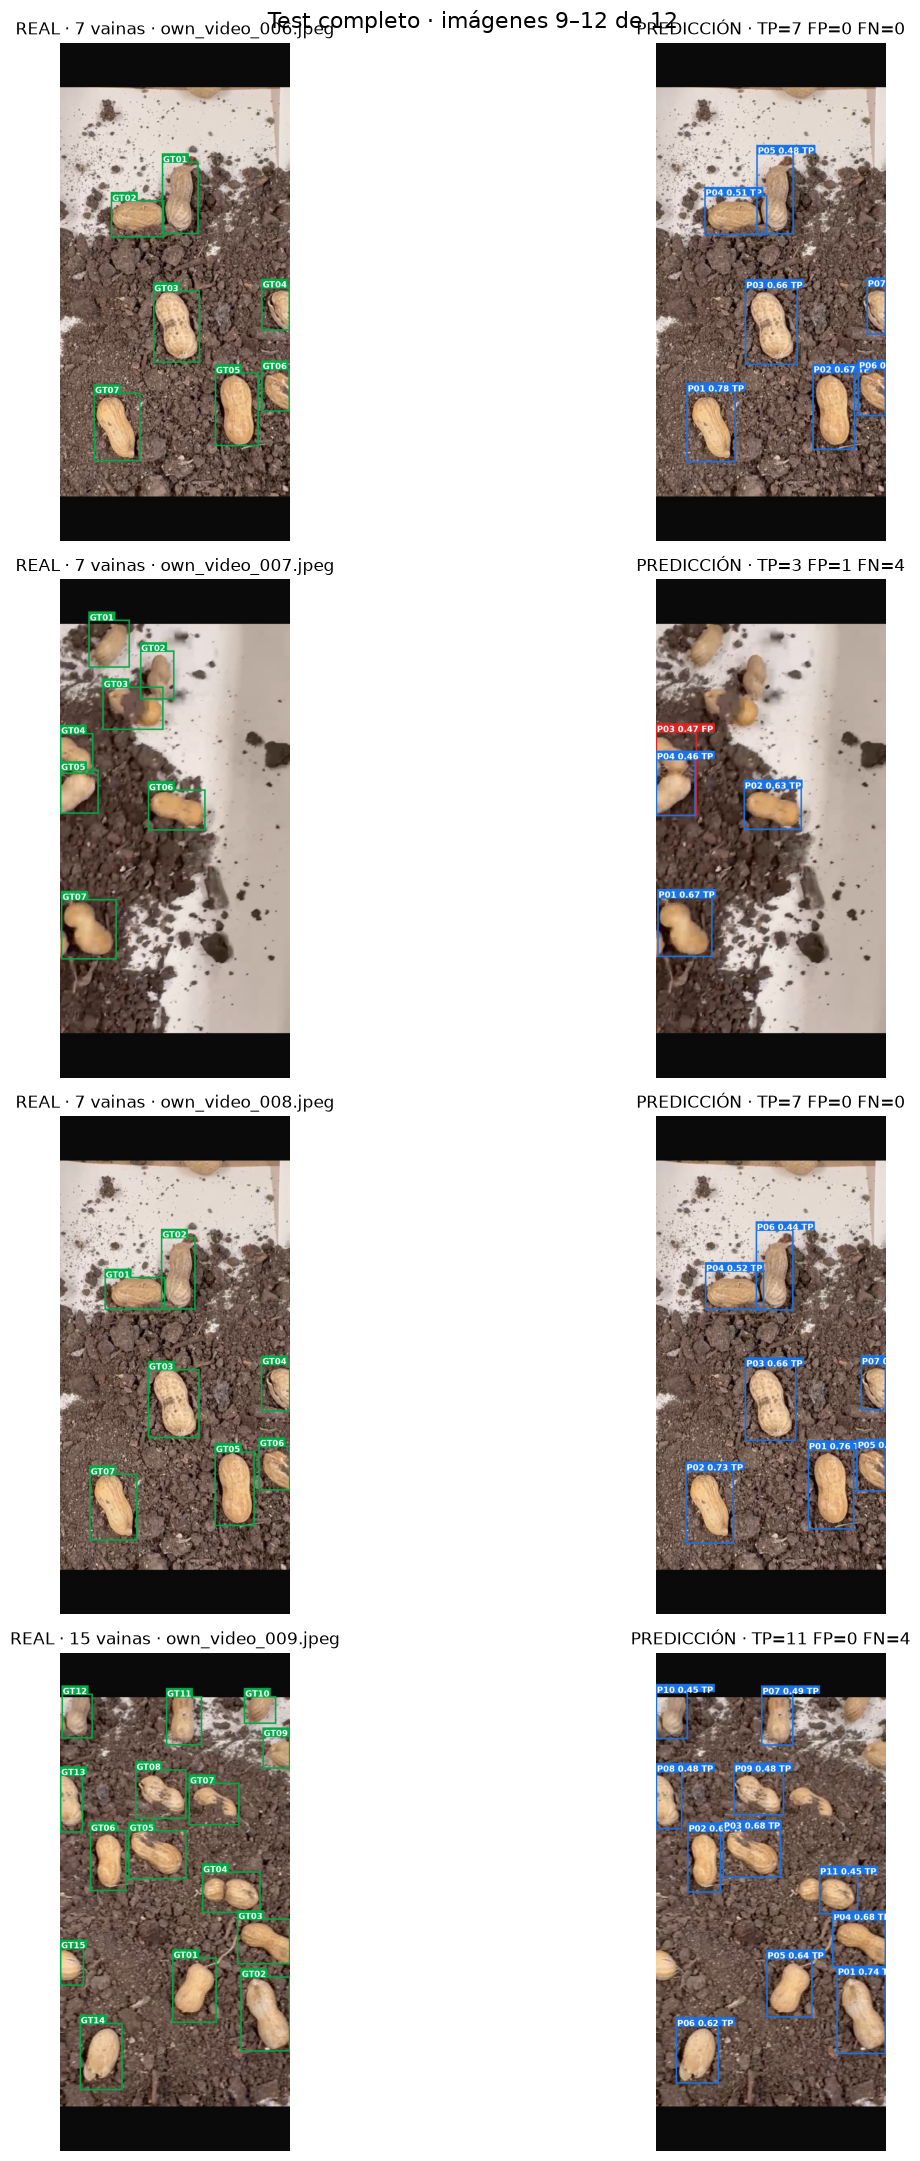

In [8]:
def get_font(image_size: tuple[int, int]) -> ImageFont.ImageFont:
    font_size = max(15, round(max(image_size) / 60))
    font_path = Path("/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf")
    if font_path.is_file():
        return ImageFont.truetype(str(font_path), font_size)
    return ImageFont.load_default()


def draw_labeled_box(
    draw: ImageDraw.ImageDraw,
    box: np.ndarray,
    label: str,
    color: tuple[int, int, int],
    line_width: int,
    font: ImageFont.ImageFont,
) -> None:
    coordinates = tuple(float(value) for value in box)
    draw.rectangle(coordinates, outline=color, width=line_width)
    left, top, _, _ = coordinates
    text_box = draw.textbbox((left, top), label, font=font)
    text_width = text_box[2] - text_box[0]
    text_height = text_box[3] - text_box[1]
    text_top = max(0, top - text_height - 6)
    draw.rectangle(
        (left, text_top, left + text_width + 8, text_top + text_height + 6),
        fill=color,
    )
    draw.text((left + 4, text_top + 2), label, fill="white", font=font)


def draw_ground_truth(analysis: dict) -> Image.Image:
    image = Image.open(analysis["image_path"]).convert("RGB")
    draw = ImageDraw.Draw(image)
    line_width = max(3, round(max(image.size) / 320))
    font = get_font(image.size)
    for index, box in enumerate(analysis["ground_truth"], start=1):
        draw_labeled_box(
            draw,
            box,
            f"GT{index:02d}",
            (0, 170, 70),
            line_width,
            font,
        )
    return image


def draw_predictions(analysis: dict) -> Image.Image:
    image = Image.open(analysis["image_path"]).convert("RGB")
    draw = ImageDraw.Draw(image)
    line_width = max(3, round(max(image.size) / 320))
    font = get_font(image.size)
    for index, (box, confidence, status) in enumerate(
        zip(
            analysis["predicted"],
            analysis["confidences"],
            analysis["statuses"],
        ),
        start=1,
    ):
        color = (25, 115, 230) if status == "TP" else (220, 35, 35)
        draw_labeled_box(
            draw,
            box,
            f"P{index:02d} {float(confidence):.2f} {status}",
            color,
            line_width,
            font,
        )
    return image


for page_start in range(0, len(analyses), IMAGES_PER_PAGE):
    page = analyses[page_start : page_start + IMAGES_PER_PAGE]
    fig, axes = plt.subplots(len(page), 2, figsize=(16, 5.5 * len(page)))
    axes = np.asarray(axes).reshape(len(page), 2)
    for row_index, analysis in enumerate(page):
        true_positives = analysis["statuses"].count("TP")
        false_positives = analysis["statuses"].count("FP")
        false_negatives = len(analysis["ground_truth"]) - true_positives
        axes[row_index, 0].imshow(draw_ground_truth(analysis))
        axes[row_index, 0].set_title(
            f"REAL · {len(analysis['ground_truth'])} vainas · "
            f"{analysis['image_path'].name}"
        )
        axes[row_index, 1].imshow(draw_predictions(analysis))
        axes[row_index, 1].set_title(
            f"PREDICCIÓN · TP={true_positives} FP={false_positives} "
            f"FN={false_negatives}"
        )
        for axis in axes[row_index]:
            axis.axis("off")
    fig.suptitle(
        f"Test completo · imágenes {page_start + 1}–{page_start + len(page)} "
        f"de {len(analyses)}",
        fontsize=16,
    )
    plt.tight_layout()
    plt.show()


## 7. Tabla completa de detecciones

Se imprime una fila por cada detección devuelta por el modelo. Las
coordenadas `x1, y1, x2, y2` están expresadas en píxeles de la imagen
original. Si una detección es TP, `GT` indica la anotación emparejada.


In [9]:
detection_rows = []
markdown_blocks = []
for analysis in analyses:
    image_name = analysis["image_path"].name
    rows = []
    for prediction_index, (
        box,
        confidence,
        status,
        gt_index,
        matched_iou,
    ) in enumerate(
        zip(
            analysis["predicted"],
            analysis["confidences"],
            analysis["statuses"],
            analysis["matched_gt"],
            analysis["matched_ious"],
        ),
        start=1,
    ):
        x1, y1, x2, y2 = [float(value) for value in box]
        row = {
            "image": image_name,
            "capture_group": analysis["capture_group"],
            "prediction": prediction_index,
            "confidence": float(confidence),
            "status": status,
            "matched_gt": None if gt_index is None else gt_index + 1,
            "iou": float(matched_iou),
            "x1": x1,
            "y1": y1,
            "x2": x2,
            "y2": y2,
        }
        detection_rows.append(row)
        rows.append(row)

    block = [
        f"### {image_name}",
        f"Grupo: `{analysis['capture_group']}` · "
        f"Original: `{analysis['original_file_name']}` · "
        f"GT: **{len(analysis['ground_truth'])}** · "
        f"Detecciones: **{len(rows)}**",
    ]
    if rows:
        table_lines = [
            "| ID | Confianza | Estado | GT | IoU | x1 | y1 | x2 | y2 |",
            "|---|---:|---|---:|---:|---:|---:|---:|---:|",
        ]
        for row in rows:
            gt_text = "—" if row["matched_gt"] is None else f"GT{row['matched_gt']:02d}"
            table_lines.append(
                f"| P{row['prediction']:02d} | {row['confidence']:.4f} | "
                f"{row['status']} | {gt_text} | {row['iou']:.3f} | "
                f"{row['x1']:.1f} | {row['y1']:.1f} | "
                f"{row['x2']:.1f} | {row['y2']:.1f} |"
            )
        block.append("\n".join(table_lines))
    else:
        block.append("*No hubo detecciones por encima del umbral.*")
    markdown_blocks.append("\n\n".join(block))

display(Markdown("\n\n---\n\n".join(markdown_blocks)))
print(
    f"Verificación: se imprimieron {len(detection_rows)} de "
    f"{sum(len(item['predicted']) for item in analyses)} detecciones."
)


### own_photo_016.jpeg

Grupo: `photos_025523` · Original: `WhatsApp Image 2026-09-12 at 02.55.23 (1).jpeg` · GT: **5** · Detecciones: **6**

| ID | Confianza | Estado | GT | IoU | x1 | y1 | x2 | y2 |
|---|---:|---|---:|---:|---:|---:|---:|---:|
| P01 | 0.6740 | TP | GT03 | 0.777 | 185.7 | 96.7 | 411.5 | 253.9 |
| P02 | 0.6666 | TP | GT04 | 0.772 | 675.6 | 91.1 | 808.8 | 310.9 |
| P03 | 0.6507 | TP | GT01 | 0.915 | 0.0 | 156.1 | 137.9 | 394.8 |
| P04 | 0.6441 | TP | GT05 | 0.804 | 276.4 | 449.3 | 522.7 | 629.0 |
| P05 | 0.5841 | TP | GT02 | 0.720 | 111.5 | 52.6 | 306.5 | 180.9 |
| P06 | 0.3552 | FP | — | 0.000 | 0.0 | 17.0 | 72.5 | 220.5 |

---

### own_photo_017.jpeg

Grupo: `photos_025523` · Original: `WhatsApp Image 2026-09-12 at 02.55.23 (2).jpeg` · GT: **8** · Detecciones: **11**

| ID | Confianza | Estado | GT | IoU | x1 | y1 | x2 | y2 |
|---|---:|---|---:|---:|---:|---:|---:|---:|
| P01 | 0.7609 | TP | GT06 | 0.882 | 144.4 | 406.1 | 280.6 | 571.1 |
| P02 | 0.7110 | TP | GT04 | 0.886 | 358.1 | 233.2 | 510.1 | 463.1 |
| P03 | 0.6397 | TP | GT08 | 0.813 | 471.3 | 136.3 | 631.1 | 258.4 |
| P04 | 0.6330 | TP | GT03 | 0.777 | 301.9 | 102.6 | 431.2 | 302.4 |
| P05 | 0.6130 | TP | GT02 | 0.865 | 547.0 | 174.8 | 752.2 | 324.2 |
| P06 | 0.5646 | FP | — | 0.000 | 0.0 | 643.6 | 152.1 | 771.8 |
| P07 | 0.5438 | TP | GT07 | 0.788 | 651.9 | 505.1 | 877.3 | 663.3 |
| P08 | 0.4507 | FP | — | 0.000 | 79.4 | 665.6 | 198.5 | 786.8 |
| P09 | 0.4471 | TP | GT01 | 0.769 | 611.0 | 23.2 | 712.4 | 210.6 |
| P10 | 0.3723 | TP | GT05 | 0.575 | 137.4 | 632.3 | 269.6 | 762.3 |
| P11 | 0.3293 | FP | — | 0.000 | 457.5 | 135.9 | 638.8 | 359.1 |

---

### own_photo_018.jpeg

Grupo: `photos_025523` · Original: `WhatsApp Image 2026-09-12 at 02.55.23.jpeg` · GT: **4** · Detecciones: **6**

| ID | Confianza | Estado | GT | IoU | x1 | y1 | x2 | y2 |
|---|---:|---|---:|---:|---:|---:|---:|---:|
| P01 | 0.8152 | TP | GT03 | 0.871 | 28.8 | 250.6 | 168.5 | 491.0 |
| P02 | 0.7799 | TP | GT02 | 0.794 | 422.8 | 608.6 | 568.7 | 852.3 |
| P03 | 0.7343 | TP | GT01 | 0.927 | 343.7 | 124.6 | 499.1 | 342.7 |
| P04 | 0.5949 | TP | GT04 | 0.777 | 700.3 | 155.8 | 918.3 | 295.0 |
| P05 | 0.5501 | FP | — | 0.000 | 812.2 | 419.8 | 960.0 | 539.4 |
| P06 | 0.4190 | FP | — | 0.000 | 320.4 | 1170.4 | 591.6 | 1280.0 |

---

### own_video_001.jpeg

Grupo: `video_burst_034724_034726` · Original: `WhatsApp Image 2026-09-12 at 03.47.24 (1).jpeg` · GT: **11** · Detecciones: **8**

| ID | Confianza | Estado | GT | IoU | x1 | y1 | x2 | y2 |
|---|---:|---|---:|---:|---:|---:|---:|---:|
| P01 | 0.7457 | TP | GT10 | 0.953 | 209.6 | 1002.8 | 359.6 | 1186.1 |
| P02 | 0.7008 | TP | GT02 | 0.839 | 159.2 | 453.7 | 318.1 | 634.3 |
| P03 | 0.6261 | TP | GT11 | 0.890 | 354.1 | 982.8 | 534.5 | 1158.0 |
| P04 | 0.5900 | TP | GT04 | 0.850 | 232.5 | 589.9 | 430.1 | 746.9 |
| P05 | 0.5765 | TP | GT09 | 0.841 | 108.3 | 919.3 | 243.6 | 1144.4 |
| P06 | 0.5291 | TP | GT05 | 0.952 | 570.6 | 641.6 | 739.0 | 774.0 |
| P07 | 0.5147 | TP | GT06 | 0.636 | 399.5 | 326.9 | 610.5 | 517.9 |
| P08 | 0.2639 | TP | GT03 | 0.793 | 252.5 | 474.6 | 413.9 | 617.2 |

---

### own_video_002.jpeg

Grupo: `video_burst_034724_034726` · Original: `WhatsApp Image 2026-09-12 at 03.47.24.jpeg` · GT: **4** · Detecciones: **4**

| ID | Confianza | Estado | GT | IoU | x1 | y1 | x2 | y2 |
|---|---:|---|---:|---:|---:|---:|---:|---:|
| P01 | 0.7026 | TP | GT03 | 0.825 | 266.8 | 1087.6 | 487.3 | 1359.6 |
| P02 | 0.5812 | TP | GT01 | 0.907 | 0.0 | 133.0 | 136.0 | 306.2 |
| P03 | 0.5806 | TP | GT04 | 0.736 | 0.0 | 1004.2 | 203.5 | 1156.4 |
| P04 | 0.3379 | TP | GT02 | 0.767 | 419.9 | 776.6 | 606.7 | 900.3 |

---

### own_video_003.jpeg

Grupo: `video_burst_034724_034726` · Original: `WhatsApp Image 2026-09-12 at 03.47.25 (1).jpeg` · GT: **10** · Detecciones: **10**

| ID | Confianza | Estado | GT | IoU | x1 | y1 | x2 | y2 |
|---|---:|---|---:|---:|---:|---:|---:|---:|
| P01 | 0.7670 | TP | GT03 | 0.744 | 177.6 | 507.9 | 312.5 | 697.8 |
| P02 | 0.7334 | TP | GT02 | 0.839 | 505.7 | 462.3 | 620.8 | 670.0 |
| P03 | 0.7067 | TP | GT08 | 0.886 | 191.2 | 1114.5 | 443.8 | 1273.7 |
| P04 | 0.6570 | TP | GT06 | 0.825 | 288.8 | 820.7 | 523.5 | 960.9 |
| P05 | 0.6552 | TP | GT10 | 0.899 | 0.0 | 1132.3 | 179.4 | 1378.7 |
| P06 | 0.6525 | TP | GT07 | 0.587 | 21.7 | 838.4 | 159.2 | 976.1 |
| P07 | 0.6460 | TP | GT09 | 0.897 | 534.9 | 1089.7 | 658.5 | 1270.8 |
| P08 | 0.6406 | TP | GT01 | 0.848 | 341.6 | 266.4 | 474.1 | 464.7 |
| P09 | 0.4904 | TP | GT05 | 0.840 | 616.8 | 454.2 | 739.0 | 613.4 |
| P10 | 0.2633 | TP | GT04 | 0.707 | 646.8 | 269.5 | 739.0 | 381.5 |

---

### own_video_004.jpeg

Grupo: `video_burst_034724_034726` · Original: `WhatsApp Image 2026-09-12 at 03.47.25 (2).jpeg` · GT: **7** · Detecciones: **4**

| ID | Confianza | Estado | GT | IoU | x1 | y1 | x2 | y2 |
|---|---:|---|---:|---:|---:|---:|---:|---:|
| P01 | 0.7049 | TP | GT05 | 0.912 | 46.0 | 965.4 | 318.9 | 1191.3 |
| P02 | 0.6328 | TP | GT06 | 0.901 | 52.1 | 1185.5 | 255.6 | 1471.3 |
| P03 | 0.5690 | TP | GT03 | 0.762 | 396.6 | 660.8 | 645.1 | 831.7 |
| P04 | 0.5677 | TP | GT04 | 0.896 | 0.0 | 805.7 | 171.7 | 958.8 |

---

### own_video_005.jpeg

Grupo: `video_burst_034724_034726` · Original: `WhatsApp Image 2026-09-12 at 03.47.25 (3).jpeg` · GT: **7** · Detecciones: **6**

| ID | Confianza | Estado | GT | IoU | x1 | y1 | x2 | y2 |
|---|---:|---|---:|---:|---:|---:|---:|---:|
| P01 | 0.7230 | TP | GT07 | 0.854 | 85.7 | 1098.6 | 238.4 | 1326.2 |
| P02 | 0.7177 | TP | GT03 | 0.911 | 274.1 | 770.4 | 439.9 | 1019.6 |
| P03 | 0.6386 | TP | GT05 | 0.891 | 474.8 | 1034.3 | 606.8 | 1289.7 |
| P04 | 0.6384 | TP | GT04 | 0.830 | 638.6 | 771.9 | 739.0 | 933.3 |
| P05 | 0.5321 | TP | GT01 | 0.719 | 152.5 | 487.2 | 342.8 | 621.1 |
| P06 | 0.3033 | TP | GT02 | 0.874 | 316.4 | 357.6 | 432.4 | 618.3 |

---

### own_video_006.jpeg

Grupo: `video_burst_034724_034726` · Original: `WhatsApp Image 2026-09-12 at 03.47.25.jpeg` · GT: **7** · Detecciones: **7**

| ID | Confianza | Estado | GT | IoU | x1 | y1 | x2 | y2 |
|---|---:|---|---:|---:|---:|---:|---:|---:|
| P01 | 0.7760 | TP | GT07 | 0.892 | 98.5 | 1118.0 | 257.5 | 1347.1 |
| P02 | 0.6675 | TP | GT05 | 0.894 | 503.0 | 1057.4 | 640.3 | 1307.8 |
| P03 | 0.6608 | TP | GT03 | 0.824 | 286.8 | 786.0 | 456.3 | 1034.1 |
| P04 | 0.5106 | TP | GT02 | 0.701 | 156.3 | 489.2 | 358.3 | 617.6 |
| P05 | 0.4781 | TP | GT01 | 0.846 | 323.6 | 354.3 | 443.3 | 615.9 |
| P06 | 0.4755 | TP | GT06 | 0.867 | 649.1 | 1044.4 | 739.0 | 1199.8 |
| P07 | 0.3030 | TP | GT04 | 0.622 | 677.1 | 780.8 | 739.0 | 937.5 |

---

### own_video_007.jpeg

Grupo: `video_burst_034724_034726` · Original: `WhatsApp Image 2026-09-12 at 03.47.26 (1).jpeg` · GT: **7** · Detecciones: **4**

| ID | Confianza | Estado | GT | IoU | x1 | y1 | x2 | y2 |
|---|---:|---|---:|---:|---:|---:|---:|---:|
| P01 | 0.6654 | TP | GT07 | 0.918 | 5.3 | 1020.4 | 182.4 | 1212.5 |
| P02 | 0.6290 | TP | GT06 | 0.935 | 282.4 | 669.5 | 469.7 | 804.1 |
| P03 | 0.4670 | FP | — | 0.000 | 0.0 | 488.5 | 132.4 | 759.8 |
| P04 | 0.4554 | TP | GT05 | 0.750 | 0.0 | 576.3 | 128.5 | 760.1 |

---

### own_video_008.jpeg

Grupo: `video_burst_034724_034726` · Original: `WhatsApp Image 2026-09-12 at 03.47.26 (2).jpeg` · GT: **7** · Detecciones: **7**

| ID | Confianza | Estado | GT | IoU | x1 | y1 | x2 | y2 |
|---|---:|---|---:|---:|---:|---:|---:|---:|
| P01 | 0.7636 | TP | GT05 | 0.792 | 488.1 | 1067.8 | 637.7 | 1327.2 |
| P02 | 0.7323 | TP | GT07 | 0.878 | 95.3 | 1136.0 | 251.8 | 1373.4 |
| P03 | 0.6564 | TP | GT03 | 0.881 | 287.0 | 801.8 | 451.8 | 1043.0 |
| P04 | 0.5214 | TP | GT01 | 0.742 | 158.1 | 495.8 | 348.5 | 622.5 |
| P05 | 0.4858 | TP | GT06 | 0.879 | 644.7 | 1063.8 | 739.0 | 1205.2 |
| P06 | 0.4374 | TP | GT02 | 0.826 | 321.4 | 364.2 | 442.2 | 624.2 |
| P07 | 0.2889 | TP | GT04 | 0.836 | 658.5 | 794.9 | 739.0 | 944.1 |

---

### own_video_009.jpeg

Grupo: `video_burst_034724_034726` · Original: `WhatsApp Image 2026-09-12 at 03.47.26.jpeg` · GT: **15** · Detecciones: **11**

| ID | Confianza | Estado | GT | IoU | x1 | y1 | x2 | y2 |
|---|---:|---|---:|---:|---:|---:|---:|---:|
| P01 | 0.7448 | TP | GT02 | 0.936 | 580.5 | 1031.6 | 739.0 | 1288.4 |
| P02 | 0.6826 | TP | GT06 | 0.897 | 101.7 | 571.7 | 210.6 | 770.6 |
| P03 | 0.6824 | TP | GT05 | 0.887 | 215.2 | 563.3 | 402.4 | 722.2 |
| P04 | 0.6808 | TP | GT03 | 0.907 | 566.6 | 855.6 | 739.0 | 1010.4 |
| P05 | 0.6434 | TP | GT01 | 0.882 | 355.2 | 979.7 | 503.5 | 1171.6 |
| P06 | 0.6208 | TP | GT14 | 0.844 | 64.8 | 1196.6 | 203.7 | 1383.8 |
| P07 | 0.4938 | TP | GT11 | 0.824 | 338.5 | 131.2 | 442.3 | 298.4 |
| P08 | 0.4783 | TP | GT13 | 0.784 | 0.0 | 380.1 | 85.4 | 568.0 |
| P09 | 0.4770 | TP | GT08 | 0.824 | 249.5 | 379.9 | 412.4 | 522.7 |
| P10 | 0.4486 | TP | GT12 | 0.885 | 0.0 | 126.6 | 103.2 | 277.5 |
| P11 | 0.4454 | TP | GT04 | 0.576 | 524.2 | 710.1 | 650.2 | 839.2 |

Verificación: se imprimieron 84 de 84 detecciones.


## 8. Diagnóstico a umbral fijo por imagen

Este cálculo usa confianza ≥ 0.25 e IoU ≥ 0.50. Es útil para localizar
errores concretos, pero no reemplaza las métricas mAP de Ultralytics,
que integran múltiples umbrales.


| Imagen | Grupo | GT | Pred | TP | FP | FN | Precision | Recall |
|---|---|---:|---:|---:|---:|---:|---:|---:|
| own_photo_016.jpeg | photos_025523 | 5 | 6 | 5 | 1 | 0 | 0.833 | 1.000 |
| own_photo_017.jpeg | photos_025523 | 8 | 11 | 8 | 3 | 0 | 0.727 | 1.000 |
| own_photo_018.jpeg | photos_025523 | 4 | 6 | 4 | 2 | 0 | 0.667 | 1.000 |
| own_video_001.jpeg | video_burst_034724_034726 | 11 | 8 | 8 | 0 | 3 | 1.000 | 0.727 |
| own_video_002.jpeg | video_burst_034724_034726 | 4 | 4 | 4 | 0 | 0 | 1.000 | 1.000 |
| own_video_003.jpeg | video_burst_034724_034726 | 10 | 10 | 10 | 0 | 0 | 1.000 | 1.000 |
| own_video_004.jpeg | video_burst_034724_034726 | 7 | 4 | 4 | 0 | 3 | 1.000 | 0.571 |
| own_video_005.jpeg | video_burst_034724_034726 | 7 | 6 | 6 | 0 | 1 | 1.000 | 0.857 |
| own_video_006.jpeg | video_burst_034724_034726 | 7 | 7 | 7 | 0 | 0 | 1.000 | 1.000 |
| own_video_007.jpeg | video_burst_034724_034726 | 7 | 4 | 3 | 1 | 4 | 0.750 | 0.429 |
| own_video_008.jpeg | video_burst_034724_034726 | 7 | 7 | 7 | 0 | 0 | 1.000 | 1.000 |
| own_video_009.jpeg | video_burst_034724_034726 | 15 | 11 | 11 | 0 | 4 | 1.000 | 0.733 |

### Agregado a confianza 0.25 e IoU 0.5

- **TP:** 77
- **FP:** 7
- **FN:** 15
- **Precision:** 0.9167
- **Recall:** 0.8370
- **F1:** 0.8750

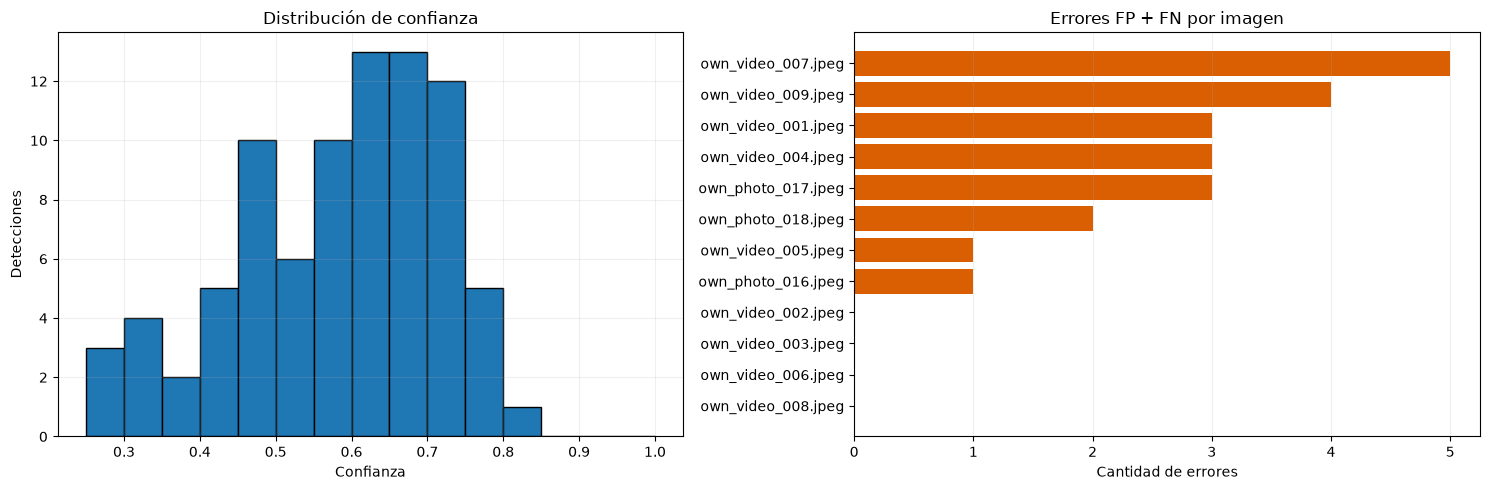

In [10]:
diagnostic_rows = []
for analysis in analyses:
    true_positives = analysis["statuses"].count("TP")
    false_positives = analysis["statuses"].count("FP")
    false_negatives = len(analysis["ground_truth"]) - true_positives
    precision = (
        true_positives / (true_positives + false_positives)
        if true_positives + false_positives
        else 0.0
    )
    recall = (
        true_positives / (true_positives + false_negatives)
        if true_positives + false_negatives
        else 0.0
    )
    diagnostic_rows.append(
        {
            "image": analysis["image_path"].name,
            "group": analysis["capture_group"],
            "gt": len(analysis["ground_truth"]),
            "pred": len(analysis["predicted"]),
            "tp": true_positives,
            "fp": false_positives,
            "fn": false_negatives,
            "precision": precision,
            "recall": recall,
        }
    )

table = [
    "| Imagen | Grupo | GT | Pred | TP | FP | FN | Precision | Recall |",
    "|---|---|---:|---:|---:|---:|---:|---:|---:|",
]
for row in diagnostic_rows:
    table.append(
        f"| {row['image']} | {row['group']} | {row['gt']} | {row['pred']} | "
        f"{row['tp']} | {row['fp']} | {row['fn']} | "
        f"{row['precision']:.3f} | {row['recall']:.3f} |"
    )
display(Markdown("\n".join(table)))

total_tp = sum(row["tp"] for row in diagnostic_rows)
total_fp = sum(row["fp"] for row in diagnostic_rows)
total_fn = sum(row["fn"] for row in diagnostic_rows)
fixed_precision = total_tp / (total_tp + total_fp) if total_tp + total_fp else 0.0
fixed_recall = total_tp / (total_tp + total_fn) if total_tp + total_fn else 0.0
fixed_f1 = (
    2 * fixed_precision * fixed_recall / (fixed_precision + fixed_recall)
    if fixed_precision + fixed_recall
    else 0.0
)
display(Markdown(
    f"### Agregado a confianza {CONFIDENCE} e IoU {MATCH_IOU}\n\n"
    f"- **TP:** {total_tp}\n"
    f"- **FP:** {total_fp}\n"
    f"- **FN:** {total_fn}\n"
    f"- **Precision:** {fixed_precision:.4f}\n"
    f"- **Recall:** {fixed_recall:.4f}\n"
    f"- **F1:** {fixed_f1:.4f}"
))

all_confidences = [row["confidence"] for row in detection_rows]
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].hist(all_confidences, bins=np.linspace(CONFIDENCE, 1, 16), edgecolor="black")
axes[0].set_title("Distribución de confianza")
axes[0].set_xlabel("Confianza")
axes[0].set_ylabel("Detecciones")
axes[0].grid(alpha=0.2)

ordered = sorted(
    diagnostic_rows,
    key=lambda row: (row["fn"] + row["fp"], row["fn"]),
    reverse=True,
)
axes[1].barh(
    [row["image"] for row in ordered],
    [row["fn"] + row["fp"] for row in ordered],
    color="#d95f02",
)
axes[1].invert_yaxis()
axes[1].set_title("Errores FP + FN por imagen")
axes[1].set_xlabel("Cantidad de errores")
axes[1].grid(axis="x", alpha=0.2)
plt.tight_layout()
plt.show()


## 9. Lectura del resultado

- El checkpoint ajustado mejora fuertemente sobre las imágenes propias:
  el modelo anterior prácticamente no detectaba este dominio.
- Para informar el resultado global use `test_metrics.json`: sus métricas
  mAP son más completas que el conteo a un solo umbral.
- Revise primero las imágenes con más `FP + FN` en la tabla y las figuras.
- El test contiene solo 12 imágenes de dos grupos de captura; por eso las
  métricas son prometedoras, pero todavía tienen alta incertidumbre.
- No use este mismo test para elegir repetidamente épocas, confianza o
  aumentaciones. Las próximas comparaciones requieren nuevas sesiones
  independientes para medir generalización real.
- Para integración use `weights/best.pt`, no `last.pt`.
